# Заревич Михаил 513-2

Вариант 169

## Анализ выборки


In [1]:
import pandas as pd
import scipy.stats
import statsmodels.graphics.gofplots
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Уровни значимости Significance level
alphas = [0.005, 0.01, 0.05]
"""Уровни значимости Significance level"""

# Соответствующие им доверительные вероятности Confidence level
gammas = [0.995, 0.99, 0.95]
"""Доверительные вероятности Confidence level"""


'Доверительные вероятности Confidence level'

In [3]:
# по умолчанию первая строчка csv файла записывается в заголовок колонки
# чтобы этого не было надо написать header = None
df = pd.read_csv("/content/v169.csv", header = None)

df = df.dropna() # убирает пропуски
df = df.sort_values(by = [0]).reset_index() # Сортировка значений
df = df.rename(columns={0: "Значения"})
df


,index,Значения
0,546,-4.052622
1,96,-3.782219
2,554,-3.273535
3,5851,-3.215289
4,471,-3.170771
...,...,...
4995,6098,3.465258
4996,3445,3.670848
4997,1117,3.672873
4998,4958,3.974495


In [4]:
# Значения разбросаны в диапазоне от -4.052622 до 4.055710.
# Диапазон можно разделить на 20 интервалов и посмотреть, сколько значений будет в каждом из них.
bins = pd.cut(df["Значения"], 20)
bins

,Значения
0,"(-4.061, -3.647]"
1,"(-4.061, -3.647]"
2,"(-3.647, -3.242]"
3,"(-3.242, -2.836]"
4,"(-3.242, -2.836]"
...,...
4995,"(3.245, 3.65]"
4996,"(3.65, 4.056]"
4997,"(3.65, 4.056]"
4998,"(3.65, 4.056]"


In [5]:
df["Интервалы"] = bins
df

,index,Значения,Интервалы
0,546,-4.052622,"(-4.061, -3.647]"
1,96,-3.782219,"(-4.061, -3.647]"
2,554,-3.273535,"(-3.647, -3.242]"
3,5851,-3.215289,"(-3.242, -2.836]"
4,471,-3.170771,"(-3.242, -2.836]"
...,...,...,...
4995,6098,3.465258,"(3.245, 3.65]"
4996,3445,3.670848,"(3.65, 4.056]"
4997,1117,3.672873,"(3.65, 4.056]"
4998,4958,3.974495,"(3.65, 4.056]"


In [6]:
# Группировка значений по интервалам.
temp = df.groupby('Интервалы')

# Группированный статистический ряд абсолютных частот.
Series = temp.agg({'Интервалы': 'count'})

print(Series)

                   Интервалы
Интервалы                   
(-4.061, -3.647]           2
(-3.647, -3.242]           1
(-3.242, -2.836]           9
(-2.836, -2.431]          27
(-2.431, -2.026]          66
(-2.026, -1.62]          147
(-1.62, -1.215]          275
(-1.215, -0.809]         471
(-0.809, -0.404]         695
(-0.404, 0.00154]        780
(0.00154, 0.407]         808
(0.407, 0.812]           701
(0.812, 1.218]           476
(1.218, 1.623]           292
(1.623, 2.029]           163
(2.029, 2.434]            58
(2.434, 2.839]            14
(2.839, 3.245]             9
(3.245, 3.65]              2
(3.65, 4.056]              4


/tmp/ipython-input-2925982853.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('Интервалы')


In [7]:
# Группированный статистический ряд абсолютных частот.
Series = Series.rename(columns={"Интервалы": "Количество значений, попавших в интервал"})
temp = df['Интервалы'].unique()
Series["Интервалы"] = temp

Series

,"Количество значений, попавших в интервал",Интервалы
Интервалы,,
"(-4.061, -3.647]",2,"(-4.061, -3.647]"
"(-3.647, -3.242]",1,"(-3.647, -3.242]"
"(-3.242, -2.836]",9,"(-3.242, -2.836]"
"(-2.836, -2.431]",27,"(-2.836, -2.431]"
"(-2.431, -2.026]",66,"(-2.431, -2.026]"
"(-2.026, -1.62]",147,"(-2.026, -1.62]"
"(-1.62, -1.215]",275,"(-1.62, -1.215]"
"(-1.215, -0.809]",471,"(-1.215, -0.809]"
"(-0.809, -0.404]",695,"(-0.809, -0.404]"


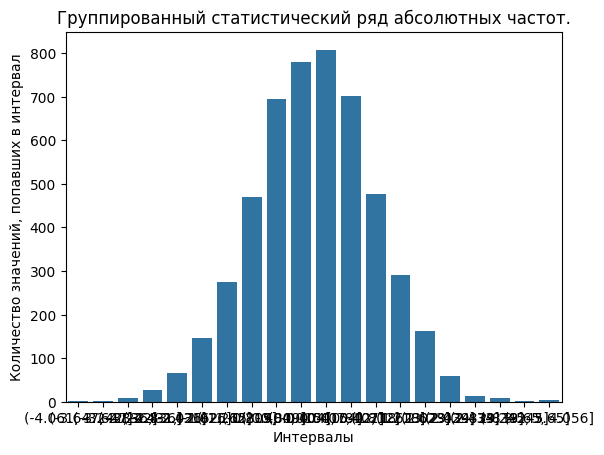

In [8]:
import seaborn as sns

x1 = Series["Интервалы"]
y = Series["Количество значений, попавших в интервал"]
sns.barplot(x=x1, y=y)
plt.title("Группированный статистический ряд абсолютных частот.")
plt.show()

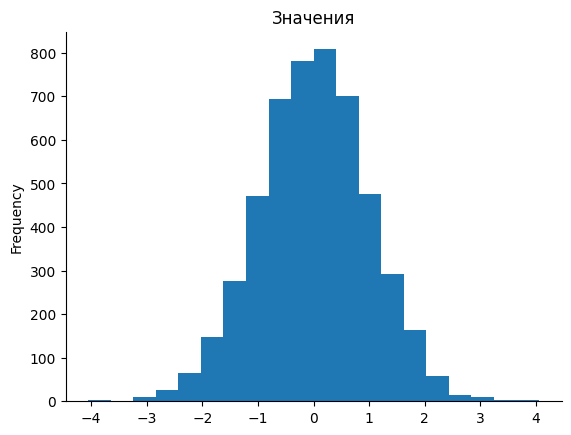

In [9]:
df['Значения'].plot(kind='hist', bins=20, title='Значения')
plt.gca().spines[['top', 'right',]].set_visible(False)

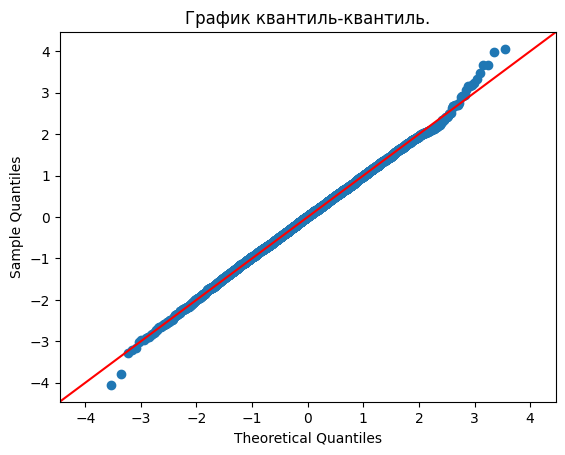

In [10]:
statsmodels.graphics.gofplots.qqplot(df["Значения"], scipy.stats.norm, line = "45")
plt.title("График квантиль-квантиль.")
plt.show()


In [11]:
print("Выборочное математическое ожидание: ", df["Значения"].mean())
print("Выборочная дисперсия: ", df["Значения"].var())
print("Выборочное ско: ", df["Значения"].std())
print("Выборочный коэффициент ассиметрии: ", df["Значения"].skew())
print("Выборочный эксцесс: ", df["Значения"].kurtosis())

Выборочное математическое ожидание:  0.006199145845556086
Выборочная дисперсия:  0.9730143456917733
Выборочное ско:  0.9864148953111835
Выборочный коэффициент ассиметрии:  -0.014846836903625062
Выборочный эксцесс:  0.15147786517018824


**Вывод.**

На основани вида графика и значений выборочных параметров можно выдвинуть гипотезу - случайная величина имеет стандартное нормальное распределение.

## Проверка гипотезы по критерию Шапиро-Уилка

Критерий Шапиро-Уилка проверяет только то, является ли распределение нормальным. Его параметры он не анализирует.

In [12]:
shapiro_test = scipy.stats.shapiro(df["Значения"])
print(shapiro_test)
print("Наблюдаемое значение критерия: ", shapiro_test[0])
print("P-значение: ", shapiro_test[1])


ShapiroResult(statistic=np.float64(0.9994041999512644), pvalue=np.float64(0.10444373368490656))
Наблюдаемое значение критерия:  0.9994041999512644
P-значение:  0.10444373368490656


Использовать наблюдаемое значение критерия трудно: так как распределение Шапиро-Уилка не имеет формулы, будет невозможно посчитать критическое значение, поэтому будем использовать только p-значение.

In [13]:
print("p-значение:", shapiro_test[1])
print("\n")

for i in range(len(alphas)):
    print("Уровень значимости: ", alphas[i])
    if (shapiro_test[1] > alphas[i]):
        print("p-value > alpha")
        print("Гипотеза принимается с доверительной вероятностью",  gammas[i])
        print("\n")

p-значение: 0.10444373368490656


Уровень значимости:  0.005
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.995


Уровень значимости:  0.01
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.99


Уровень значимости:  0.05
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.95




**Вывод.**

Гипотеза принимается при всех заданных уровнях значимости.

Чтобы проверить именно стандартное нормальное распределение n(0,1) воспользуемся другими критериями.

## Проверка гипотезы по критерию Колмогорова-Смирнова

Проверка происходит аналогично заданию №3.

In [14]:
KSTest = scipy.stats.kstest(df["Значения"] , "norm", args = (0, 1))
print("Наблюдаемое значение критерия: ", KSTest[0])
print("P-значение: ", KSTest[1])


Наблюдаемое значение критерия:  0.010775597110358026
P-значение:  0.603166763686511


**Вывод.**

Проверка гипотезы по наблюдаемому значению критерия.

Критерий Колмогорова-Смирнова имеет правостороннюю критическую область $D> d_\alpha$. Следовательно, нулевая гипотеза $H_0$ принимается при
$d_0<d_\alpha$

In [17]:
print("Наблюдаемое значение критерия d0:", KSTest[0])
print("\n")
for i in range(len(gammas)):
    d_alpha = scipy.stats.kstwo.ppf(gammas[i], len(df))
    print("Критическое значение d_alpha: ", d_alpha)
    if (KSTest[0] < d_alpha):
        print("d_0 < d_alpha")
        print("Гипотеза принимается с доверительной вероятностью", gammas[i])
        print("\n")


Наблюдаемое значение критерия d0: 0.010775597110358026


Критическое значение d_alpha:  0.024443073826368178
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.995


Критическое значение d_alpha:  0.022983922603082615
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.99


Критическое значение d_alpha:  0.019172751333714884
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.95




Проверка через pvalue.

Из документации: We choose a confidence level of 95%; that is, we will reject the null hypothesis in favor of the alternative if the p-value is less than 0.05.

Т.е. нулевая гипотеза отвергается, если pvalue меньше заданного уровня значимости, и принимается - если больше.


In [16]:
print("p-значение:", KSTest[1])
print("\n")

for i in range(len(alphas)):
    print("Уровень значимости: ", alphas[i])
    if (KSTest[1] > alphas[i]):
        print("p-value > alpha")
        print("Гипотеза принимается с доверительной вероятностью",  gammas[i])
        print("\n")

p-значение: 0.603166763686511


Уровень значимости:  0.005
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.995


Уровень значимости:  0.01
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.99


Уровень значимости:  0.05
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.95




## Проверка гипотезы по критерию хи-квадрат

Провека происходит аналогично заданию №3


Проверка по наблюдаемому значению критеория.

Если $\chi^2_0 < \chi^2_{1-\alpha, k-1}$, то нулевая гипотеза $H_0$ принимается. Иначе нулевая гипотеза отклоняется.

См. Теория вероятностей и математическая статистика, Фадеева, Лебедев. стр 354 и 357.

Значение двух параметров нормального распределения 0 и 1 я нашёл из выборки, они не были даны заранее. Поэтому количество степеней свободы распределения хи-квадрат нужно уменьшить на 2, т.е. $\chi^2_0 < \chi^2_{1-\alpha, k-1-r}$.

Зададим вероятности попадания в интервалы.

In [18]:
# Normal distribution
# Нормальное распределение
NormDist = scipy.stats.norm()
ExpectedFrequencies = []

print("Вероятности: ")

for i in temp:
    # вероятность попадания в интервал.
    Pi = NormDist.cdf(i.right)- NormDist.cdf(i.left)
    print(Pi)
    ExpectedFrequencies.append(Pi*len(df))
print()
print("Частоты: ")
for i in ExpectedFrequencies:
    print(i)

Вероятности: 
0.00010822847634354209
0.0004608101499882757
0.0016906521885094714
0.005244484979456914
0.013853785041889822
0.03123374613230592
0.059566907236682176
0.09707452744557088
0.1338487864516379
0.15750801128083486
0.1573816350337216
0.1336081783506693
0.09678382937411034
0.05931728393865798
0.031065557276996114
0.013762647612642898
0.005203739698495413
0.0016755047274480406
0.0004561329638599343
0.00010616002482588538

Частоты: 
0.5411423817177105
2.3040507499413785
8.453260942547358
26.22242489728457
69.26892520944911
156.1687306615296
297.8345361834109
485.3726372278544
669.2439322581895
787.5400564041743
786.908175168608
668.0408917533465
483.9191468705517
296.58641969328994
155.32778638498058
68.81323806321448
26.018698492477064
8.377523637240202
2.2806648192996715
0.5308001241294269


При таком разбиении у крайних интервалов оказались очень низкие ожидаемые частоты. Для работы критерия хи-квадрат лучше, чтобы эти частоты были больше 5 или 10.
Объединим первые три интервала и последние три, чтобы в них были нормальные частоты.

In [20]:
# observed_frequencies и expeced_frequencies
obs = np.array(Series["Количество значений, попавших в интервал"])
exp = np.array(ExpectedFrequencies)


# Объединение слева
while exp[0] < 10:
    obs[1] += obs[0]
    exp[1] += exp[0]
    # Удаление первого элемента
    obs = obs[1:]
    exp = exp[1:]

# Объединение справа
while exp[-1] < 10:

    obs[-2] += obs[-1]
    exp[-2] += exp[-1]
    # Удаление последнего элемента
    obs = obs[:-1]
    exp = exp[:-1]


In [23]:
for i in exp:
    print(i)

11.298454074206447
26.22242489728457
69.26892520944911
156.1687306615296
297.8345361834109
485.3726372278544
669.2439322581895
787.5400564041743
786.908175168608
668.0408917533465
483.9191468705517
296.58641969328994
155.32778638498058
68.81323806321448
26.018698492477064
11.1889885806693


In [24]:
Chi_test = scipy.stats.chisquare(obs, exp, ddof = 2,  sum_check = False)
print(Chi_test)
print("Наблюдаемое значение критерия d0: ", Chi_test[0])
print("P-значение: ", Chi_test[1])

Power_divergenceResult(statistic=np.float64(15.318771538028892), pvalue=np.float64(0.28787740387486666))
Наблюдаемое значение критерия d0:  15.318771538028892
P-значение:  0.28787740387486666


In [25]:
print("Наблюдаемое значение критерия d0:", Chi_test[0])
print("\n")
for i in range(len(gammas)):
    d_alpha = scipy.stats.chi2.ppf(gammas[i], len(Series)-1-2)
    print("Критическое значение d_alpha: ", d_alpha)
    if (Chi_test[0] < d_alpha):
        print("d_0 < d_alpha")
        print("Гипотеза принимается с доверительной вероятностью", gammas[i])
        print("\n")


Наблюдаемое значение критерия d0: 15.318771538028892


Критическое значение d_alpha:  35.71846565900461
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.995


Критическое значение d_alpha:  33.40866360500461
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.99


Критическое значение d_alpha:  27.58711163827534
d_0 < d_alpha
Гипотеза принимается с доверительной вероятностью 0.95




In [26]:
print("p-значение:", Chi_test[1])
print("\n")

for i in range(len(alphas)):
    print("Уровень значимости: ", alphas[i])
    if (Chi_test[1] > alphas[i]):
        print("p-value > alpha")
        print("Гипотеза принимается с доверительной вероятностью",  gammas[i])
        print("\n")

p-значение: 0.28787740387486666


Уровень значимости:  0.005
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.995


Уровень значимости:  0.01
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.99


Уровень значимости:  0.05
p-value > alpha
Гипотеза принимается с доверительной вероятностью 0.95


